In [2]:
import pandas as pd
import numpy as np

data1 = pd.read_csv('Data/Ride Requests_2025-11-11-part-1.csv')
data2 = pd.read_csv('Data/Ride Requests_2025-11-11-part-2.csv')
data = pd.concat([data1, data2], ignore_index=True)
# data.to_csv('Data/rides.csv', index=False)

In [ ]:
data

In [ ]:
data1

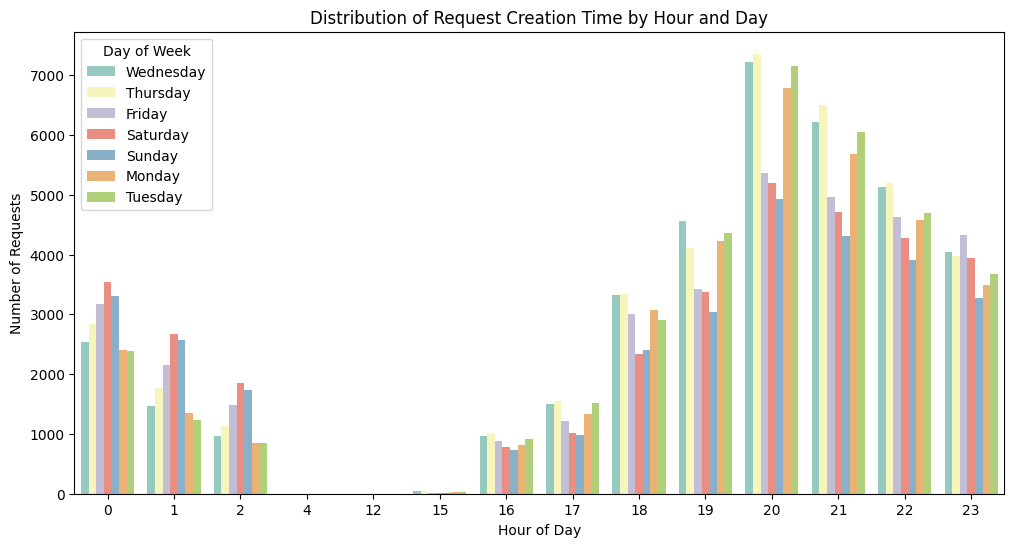

In [3]:
# visualize Request Creation Time distribution by day/hour
import matplotlib.pyplot as plt
import seaborn as sns
data['Request Creation Time'] = pd.to_datetime(data['Request Creation Time'])
data['Request Day'] = data['Request Creation Time'].dt.day_name()
data['Request Hour'] = data['Request Creation Time'].dt.hour
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='Request Hour', hue='Request Day', palette='Set3')
plt.title('Distribution of Request Creation Time by Hour and Day')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Requests')
plt.legend(title='Day of Week')
plt.show()

Two busiest hours: [20, 21]
hour
20    23442
21    22473
22    21675
23    19239
19    16552
Name: count, dtype: int64


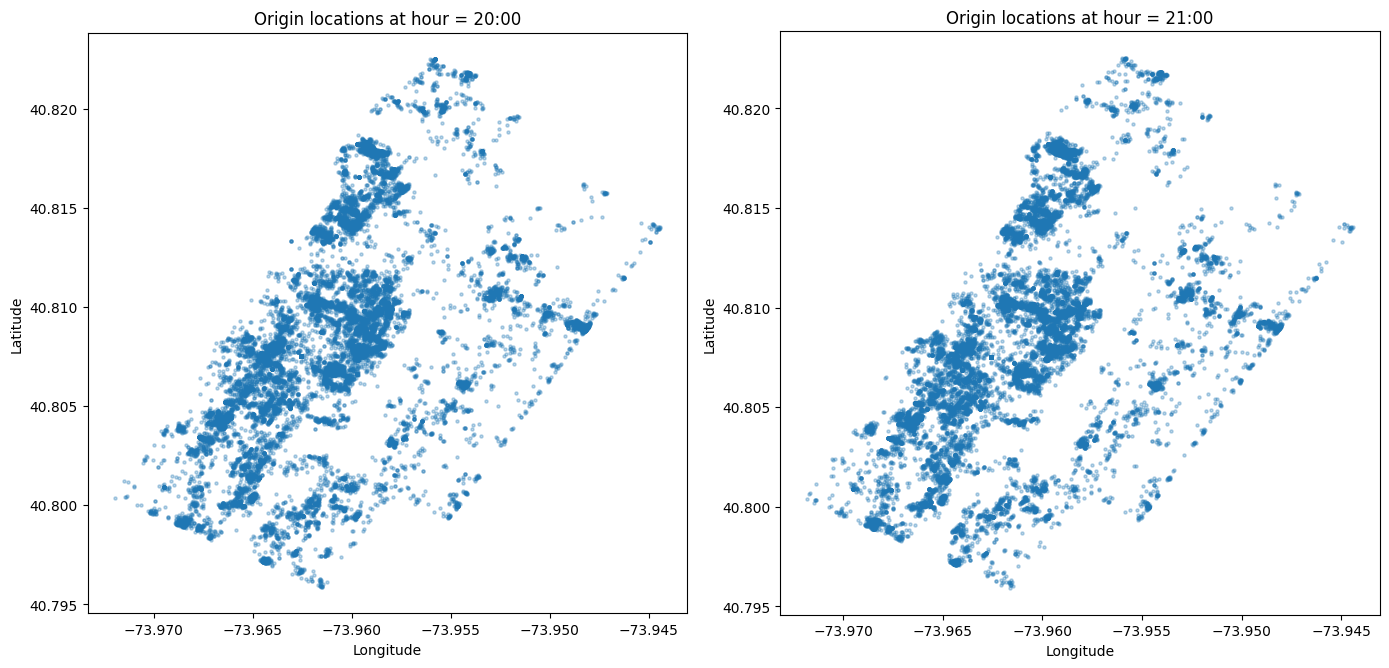

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("Data/rides.csv")

# 2. Parse datetime and extract hour (using Actual Pickup Time)
time_col = "Actual Pickup Time"   # you can change to "Request Creation Time" if you prefer

# Convert to datetime, ignore rows where conversion fails (NaT)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df_valid = df.dropna(subset=[time_col]).copy()

# Extract hour of day (0–23)
df_valid["hour"] = df_valid[time_col].dt.hour

# 3. Find the 2 busiest hours by ride count
hour_counts = df_valid["hour"].value_counts().sort_values(ascending=False)
busy_hours = hour_counts.index[:2].tolist()
print("Two busiest hours:", busy_hours.tolist() if hasattr(busy_hours, "tolist") else busy_hours)
print(hour_counts.head())

# 4. Plot Origin Lat/Lng for these hours
fig, axes = plt.subplots(1, len(busy_hours), figsize=(7 * len(busy_hours), 7), squeeze=False)
axes = axes[0]  # unpack row

for ax, hour in zip(axes, busy_hours):
    subset = df_valid[df_valid["hour"] == hour]

    # Scatter plot of origins
    ax.scatter(
        subset["Origin Lng"], 
        subset["Origin Lat"],
        s=5, alpha=0.3
    )

    ax.set_title(f"Origin locations at hour = {hour}:00")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")  # keep correct geographic aspect ratio

plt.tight_layout()
plt.show()


Two busiest hours: [20, 21]
hour
20    23442
21    22473
22    21675
23    19239
19    16552
Name: count, dtype: int64


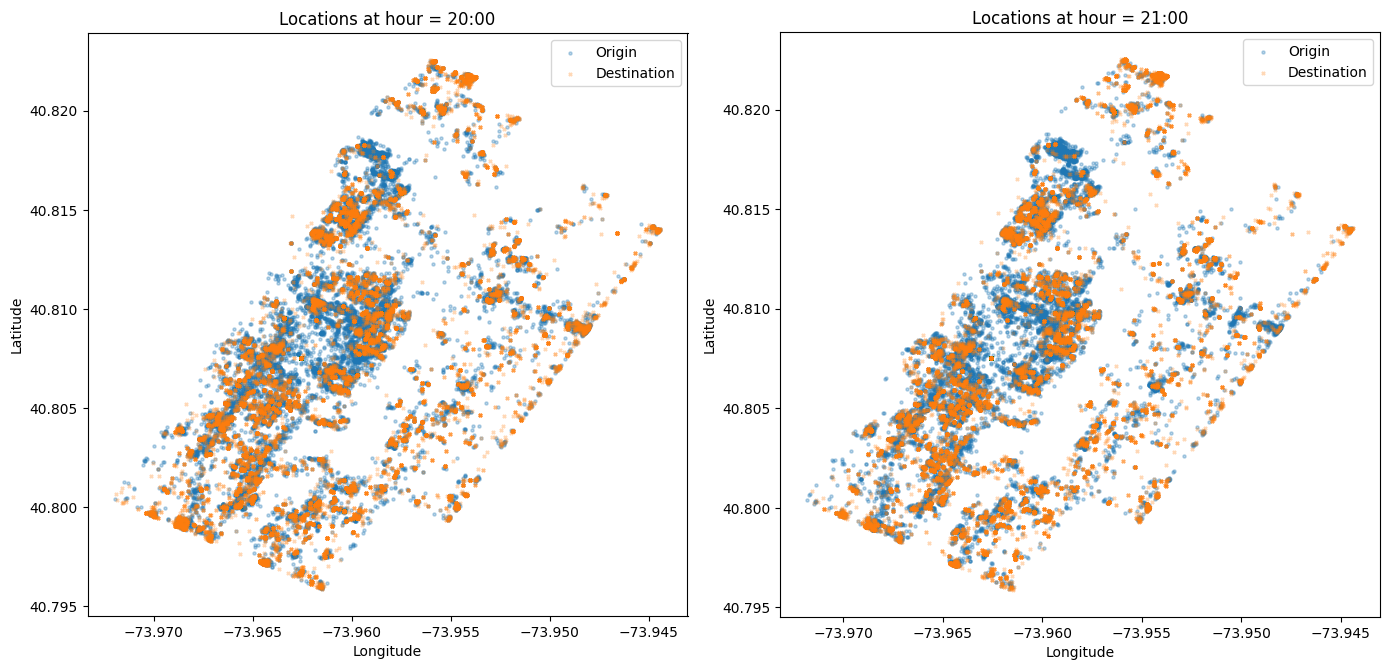

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("Data/rides.csv")

# 2. Parse datetime and extract hour (using Actual Pickup Time)
time_col = "Actual Pickup Time"   # change to "Request Creation Time" if needed

df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df_valid = df.dropna(subset=[time_col]).copy()

# Extract hour of day (0–23)
df_valid["hour"] = df_valid[time_col].dt.hour

# 3. Find the 2 busiest hours by ride count
hour_counts = df_valid["hour"].value_counts().sort_values(ascending=False)
busy_hours = hour_counts.index[:2].tolist()
print("Two busiest hours:", busy_hours)
print(hour_counts.head())

# 4. Plot Origin and Destination Lat/Lng for these hours
fig, axes = plt.subplots(1, len(busy_hours), figsize=(7 * len(busy_hours), 7), squeeze=False)
axes = axes[0]  # unpack the single row

for ax, hour in zip(axes, busy_hours):
    subset = df_valid[df_valid["hour"] == hour]

    # Origins
    ax.scatter(
        subset["Origin Lng"],
        subset["Origin Lat"],
        s=5,
        alpha=0.3,
        label="Origin"
    )

    # Destinations
    ax.scatter(
        subset["Destination Lng"],
        subset["Destination Lat"],
        s=5,
        alpha=0.3,
        marker="x",
        label="Destination"
    )

    ax.set_title(f"Locations at hour = {hour}:00")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_aspect("equal")  # keep geographic aspect ratio
    ax.legend()

plt.tight_layout()
plt.show()


Busiest week (completed only): year=2025, ISO week=7
Completed requests in that week: 7294
hour
0      436
1      300
2      202
15      32
16     546
17     798
18     935
19    1028
20     918
21     749
22     726
23     624
Name: count, dtype: int64


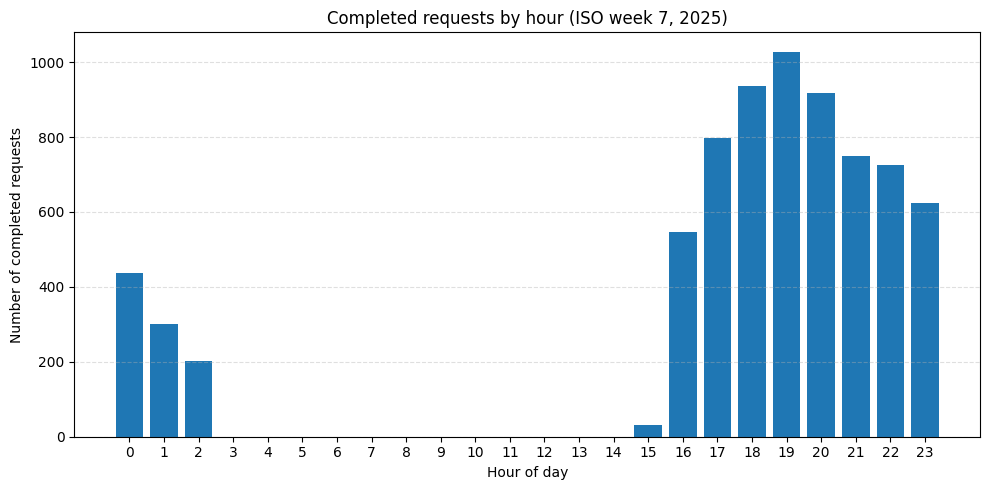

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("Data/rides.csv")

# 2. Parse Request Creation Time to datetime
time_col = "Request Creation Time"
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# 3. Keep only completed requests
# 👇 Adjust `status_col` and `completed_value` if your column is named differently
status_col = "Status"          # e.g. "Status" or "Request Status" in your CSV
completed_value = "Completed"

df = df[df['Request Status'] == completed_value].copy()

# Drop rows where time is missing
df = df.dropna(subset=[time_col]).copy()

# 4. Extract year + ISO week to define weeks
iso = df[time_col].dt.isocalendar()
df["iso_year"] = iso.year
df["iso_week"] = iso.week

# 5. Find the busiest week (most completed requests)
week_counts = (
    df.groupby(["iso_year", "iso_week"])
      .size()
      .sort_values(ascending=False)
)

busiest_year, busiest_week = week_counts.index[0]
print(f"Busiest week (completed only): year={busiest_year}, ISO week={busiest_week}")
print("Completed requests in that week:", week_counts.iloc[0])

# 6. Filter to that busiest week
week_df = df[(df["iso_year"] == busiest_year) & (df["iso_week"] == busiest_week)].copy()

# 7. Compute requests by hour of day (0–23) within that week
week_df["hour"] = week_df[time_col].dt.hour
hour_counts = week_df["hour"].value_counts().sort_index()

print(hour_counts)

# 8. Plot: Completed requests by hour of day for that week
plt.figure(figsize=(10, 5))
plt.bar(hour_counts.index, hour_counts.values)
plt.xticks(range(0, 24))
plt.xlabel("Hour of day")
plt.ylabel("Number of completed requests")
plt.title(f"Completed requests by hour (ISO week {busiest_week}, {busiest_year})")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Completed requests in selected week: 4235
hour
0     339
1     226
2     148
17     45
18    493
19    645
20    703
21    614
22    546
23    476
Name: count, dtype: int64


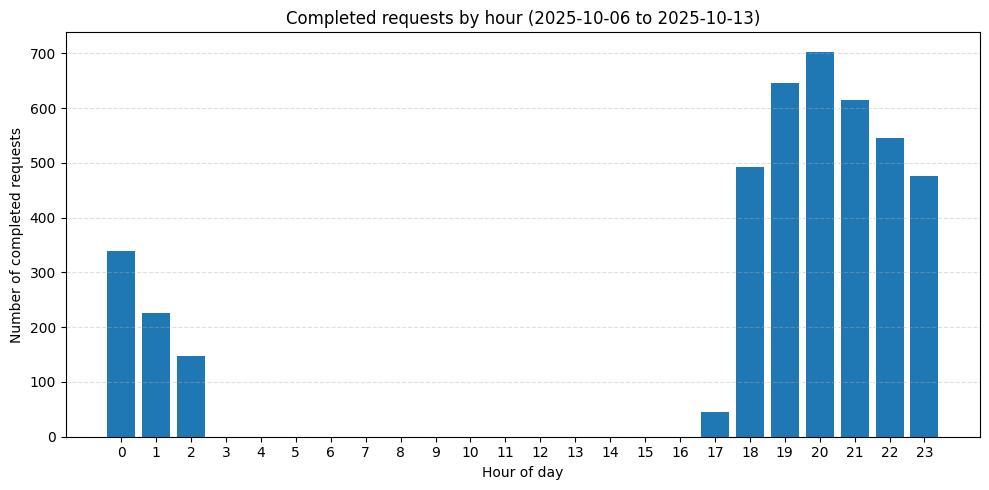

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("Data/rides.csv")

# 2. Parse Request Creation Time to datetime
time_col = "Request Creation Time"
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# 3. Keep only completed requests
completed_value = "Completed"
df = df[df["Request Status"] == completed_value].copy()

# Drop rows where time is missing
df = df.dropna(subset=[time_col]).copy()

# 4. Choose a week in October 2025
# Example: Monday 2025-10-06 to Monday 2025-10-13 (end is exclusive)
start_date = "2025-10-06"
end_date   = "2025-10-13"   # exclusive

mask = (df[time_col] >= start_date) & (df[time_col] < end_date)
week_df = df[mask].copy()

print(f"Completed requests in selected week: {len(week_df)}")

# 5. Compute requests by hour of day (0–23) within that week
week_df["hour"] = week_df[time_col].dt.hour
hour_counts = week_df["hour"].value_counts().sort_index()
print(hour_counts)

# 6. Plot: Completed requests by hour of day for that October week
plt.figure(figsize=(10, 5))
plt.bar(hour_counts.index, hour_counts.values)
plt.xticks(range(0, 24))
plt.xlabel("Hour of day")
plt.ylabel("Number of completed requests")
plt.title(f"Completed requests by hour ({start_date} to {end_date})")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Completed requests in selected week: 1800
minute
2025-01-01 00:01:00    1
2025-01-01 00:04:00    1
2025-01-01 00:06:00    1
2025-01-01 00:07:00    1
2025-01-01 00:09:00    1
dtype: int64


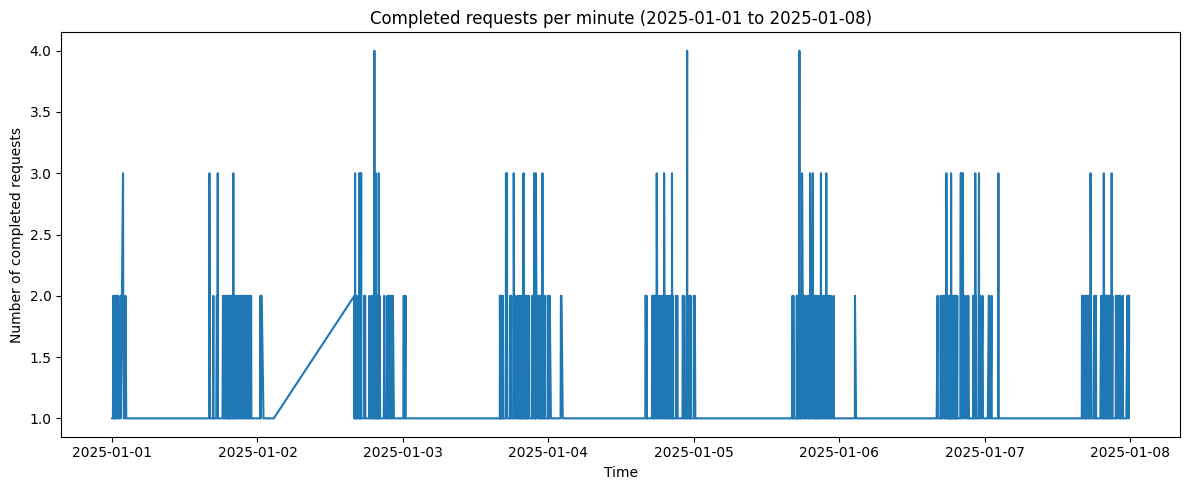

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("Data/rides.csv")

# 2. Parse Request Creation Time to datetime
time_col = "Request Creation Time"
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")

# 3. Keep only completed requests
completed_value = "Completed"
df = df[df["Request Status"] == completed_value].copy()

# Drop rows where time is missing
df = df.dropna(subset=[time_col]).copy()

# 4. Choose a week (EDIT THESE DATES TO THE WEEK YOU WANT)
# Example: 2025-01-01 to 2025-01-08 (end is exclusive)
start_date = "2025-01-01"
end_date   = "2025-01-08"   # exclusive

mask = (df[time_col] >= start_date) & (df[time_col] < end_date)
week_df = df[mask].copy()

print(f"Completed requests in selected week: {len(week_df)}")

# 5. Aggregate by minute (floor to the minute)
week_df["minute"] = week_df[time_col].dt.floor("min")

minute_counts = (
    week_df
    .groupby("minute")
    .size()
    .sort_index()
)

print(minute_counts.head())

# 6. Plot: Completed requests per minute over the week
plt.figure(figsize=(12, 5))
plt.plot(minute_counts.index, minute_counts.values)
plt.xlabel("Time")
plt.ylabel("Number of completed requests")
plt.title(f"Completed requests per minute ({start_date} to {end_date})")
plt.tight_layout()
plt.show()


In [ ]:
minute_counts